# Análisis de Variables de Referencia (OHLCV)

En análisis financiero, las variables **Open, High, Low, Close y Volume** se denominan "Variables de Referencia" o datos crudos. A diferencia de los retornos logarítmicos, estas variables capturan la **acción directa del precio** y la **liquidez** del mercado.

### ¿Por qué son variables de referencia?
1. **No son estacionarias:** Los precios suelen tener tendencias (suben o bajan con el tiempo), por lo que su media y varianza cambian. Esto impide aplicarles pruebas de normalidad de forma directa, pero las hace ideales para identificar soportes, resistencias y tendencias macro.
2. **Contexto Operativo:** Representan los puntos exactos donde compradores y vendedores acordaron intercambiar valor.
3. **Liquidez (Volumen):** Es el validador de los movimientos de precio. Un movimiento de precio sin volumen se considera "ruido" o falta de convicción.

---

## Paso 1: Configuración e Inspección de Magnitudes

En este primer bloque, establecemos la base y observamos las estadísticas descriptivas. Como futuros profesionales de la ciencia de datos transponemos la tabla (.T) porque es mucho más fácil leer 5 variables como filas que como columnas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 1. Carga y preparación
df = pd.read_csv('items/XRP_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# --- A. ESTADÍSTICOS DESCRIPTIVOS ---
# Analizamos la escala de los datos y buscamos inconsistencias iniciales
print("--- Resumen Estadístico de Variables OHLCV ---")
summary = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().T
# Añadimos Coeficiente de Variación (CV) para medir volatilidad relativa
summary['cv'] = summary['std'] / summary['mean']
display(summary.style.format("{:,.4f}"))

--- Resumen Estadístico de Variables OHLCV ---


,count,mean,std,min,25%,50%,75%,max,cv
Open,"3,044.0000",0.8105,0.7456,0.1405,0.3345,0.5167,0.8596,3.5556,0.9199
High,"3,044.0000",0.8388,0.7725,0.1469,0.3454,0.5273,0.8933,3.8419,0.9210
Low,"3,044.0000",0.7808,0.7185,0.1151,0.3250,0.5019,0.8232,3.4308,0.9203
Close,"3,044.0000",0.8109,0.7456,0.1396,0.3350,0.5171,0.8609,3.5558,0.9195
Volume,"3,044.0000","2,883,614,025.3771","3,871,340,770.3501","100,294,000.0000","953,323,593.2500","1,625,302,871.5000","3,192,528,347.5000","51,723,383,809.0000",1.3425


### 📊 Interpretación del Resumen Estadístico (OHLCV)

El análisis descriptivo de las 3,044 observaciones revela una estructura de mercado con las siguientes características:

1. **Análisis de la Escala y Sesgo**: Se observa que la **media ($0.81)** se sitúa significativamente por encima de la **mediana ($0.51)**. Esto confirma una distribución con sesgo positivo, donde el activo tiende a cotizar en rangos bajos la mayor parte del tiempo, con incursiones esporádicas hacia precios elevados.

2. **Volatilidad Relativa (CV)**: El Coeficiente de Variación (CV) para los precios se mantiene constante en **0.919**, indicando una dispersión alta pero uniforme entre las métricas OHLC. Sin embargo, el **CV del Volumen (1.34)** supera al del precio, confirmando que la actividad comercial es el componente más errático y propenso a choques de volatilidad en este dataset.

3. **Integridad de los Datos**: Los valores extremos validan la jerarquía lógica del mercado ($Low \leq Open/Close \leq High$). El rango histórico total (desde un mínimo de **$0.11** hasta un máximo de **$3.84**) demuestra que XRP es un activo de alta beta con una capacidad de expansión de precio superior al 3,000% desde su punto más bajo.

4. **Concentración de Liquidez**: El 75% de los días de negociación registran volúmenes por debajo de los **3.19 mil millones**, mientras que el máximo alcanza los **51.7 mil millones**. Esta asimetría sugiere que los movimientos de precio de gran magnitud están concentrados en una fracción muy pequeña de la historia del activo (días de alto impacto).

## Paso 2: Análisis de la Acción del Precio (Tendencia Macro)

Separamos el gráfico de precio del de volumen para que el precio tenga todo el protagonismo. Usaremos una escala logarítmica opcional si el activo ha crecido varios órdenes de magnitud.

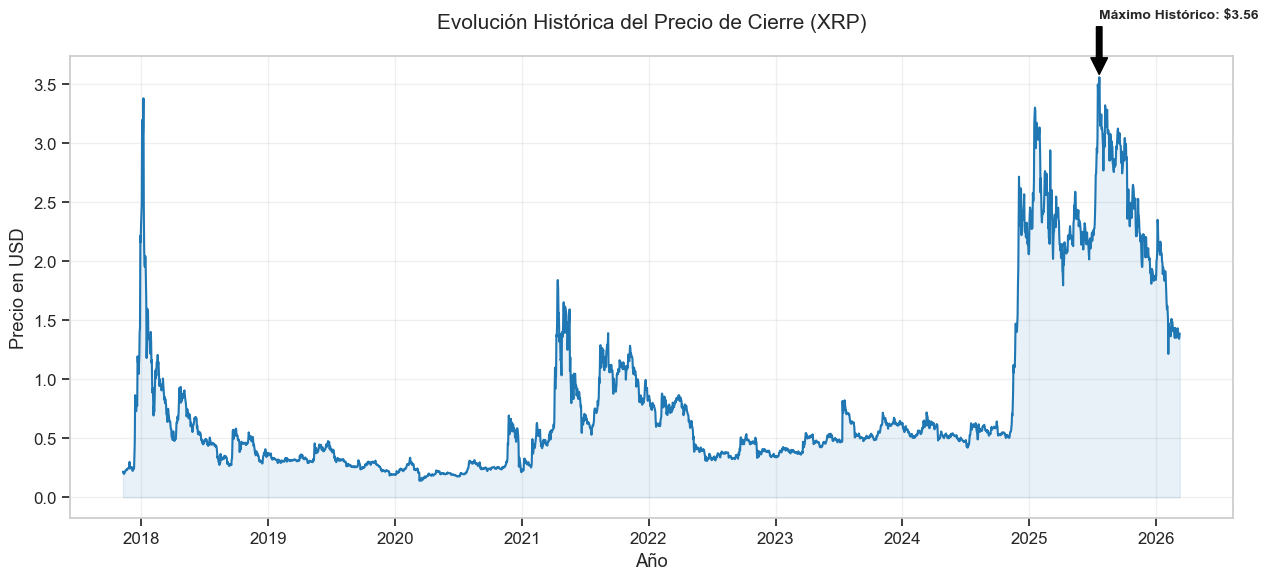

In [3]:
# --- B. EVOLUCIÓN DEL PRECIO DE CIERRE ---
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='XRP Close Price')

# Resaltar el máximo histórico para dar contexto
max_price = df['Close'].max()
max_date = df['Close'].idxmax()
plt.annotate(f'Máximo Histórico: ${max_price:.2f}', 
             xy=(max_date, max_price), xytext=(max_date, max_price + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, fontweight='bold')

plt.title('Evolución Histórica del Precio de Cierre (XRP)', fontsize=15, pad=20)
plt.ylabel('Precio en USD')
plt.xlabel('Año')
plt.fill_between(df.index, df['Close'], color='#1f77b4', alpha=0.1)
plt.grid(True, alpha=0.3)
plt.show()

### 📈 Conclusiones del Análisis de Tendencia Histórica (Serie Temporal)

El gráfico de evolución histórica permite entender la trayectoria del activo y su comportamiento cíclico a lo largo del tiempo:

1. **Naturaleza de Crecimiento Parabólico**: XRP no muestra un crecimiento lineal constante, sino que se mueve mediante "impulsos" o picos de euforia. Se identifican claramente tres grandes eventos de mercado: el rally de 2018, la recuperación de 2021 y el ciclo expansivo más reciente.

2. **Validación del Máximo Histórico (ATH)**: Se identifica el punto de mayor resistencia técnica en los **$3.56**. Este valor es una referencia crítica, ya que representa el techo psicológico del mercado en el periodo analizado.

3. **Fases de Acumulación y Soporte**: El gráfico revela largos periodos (especialmente entre 2019 y 2020) donde el precio se mantiene "plano" cerca de niveles mínimos. Estas zonas actúan como soportes históricos donde el activo tiende a estabilizarse antes de un nuevo movimiento alcista.

4. **Análisis de la Pendiente Reciente**: El movimiento observado desde finales de 2024 hasta 2025 muestra una estructura de crecimiento más vertical que en años anteriores, lo que sugiere un incremento en la presión de compra o un cambio en los fundamentos del mercado en el tramo final del dataset.

## Paso 3: Análisis de Liquidez y Validación de Movimientos
El volumen nos dice si el mercado "cree" en el precio. Un pico de volumen con un precio plano suele indicar acumulación o distribución de manos fuertes.

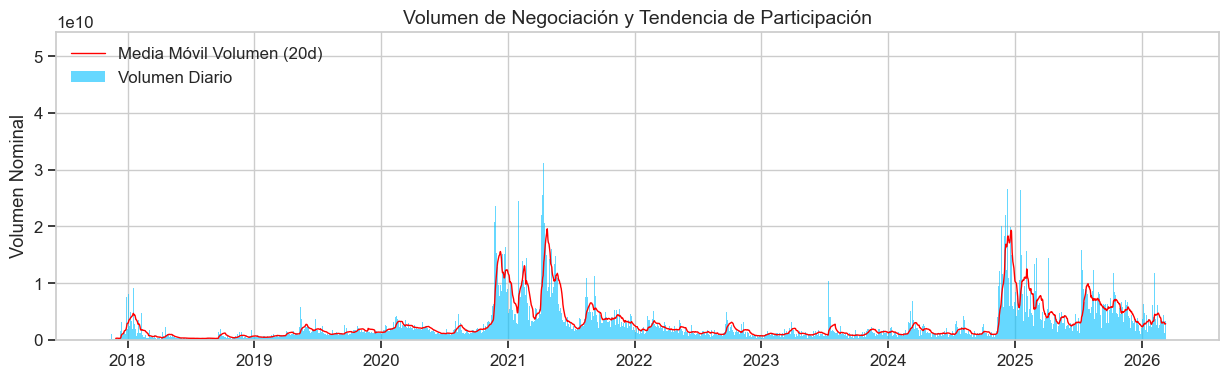

In [7]:
# --- C. ANÁLISIS DE VOLUMEN (LIQUIDEZ) ---
plt.figure(figsize=(15, 4))
plt.bar(df.index, df['Volume'], color='deepskyblue', alpha=0.6, width=1, label='Volumen Diario')

# Añadir una media móvil al volumen para ver la tendencia de participación
df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
plt.plot(df.index, df['Volume_MA20'], color='red', linewidth=1, label='Media Móvil Volumen (20d)')

plt.title('Volumen de Negociación y Tendencia de Participación', fontsize=14)
plt.ylabel('Volumen Nominal')
plt.legend()
plt.show()

### 📊 Conclusiones del Análisis de Volumen y Liquidez

El estudio de la actividad comercial proporciona una capa de validación crítica para el comportamiento del precio de XRP:

1. **Validación de la Fuerza del Mercado**: El incremento sustancial del volumen a finales de 2024 y principios de 2025 coincide con el máximo histórico de precios. Este fenómeno confirma una "convergencia precio-volumen", sugiriendo que la tendencia alcista estuvo respaldada por una entrada masiva de liquidez y no por baja profundidad de mercado.

2. **Tendencia de Participación (MA20)**: La media móvil de 20 días revela que el interés institucional y minorista ha crecido de forma estructural en el último tramo del dataset. La pendiente positiva de la línea roja indica un mercado mucho más "profundo" y líquido en 2025 en comparación con los ciclos de 2018 o 2021.

3. **Identificación de Picos de Euforia**: Los picos aislados de volumen que superan las $2.0 \times 10^{10}$ unidades suelen actuar como indicadores de agotamiento o clímax de mercado. En la serie temporal, estos eventos preceden a menudo a periodos de corrección o lateralización.

4. **Análisis de Capacidad Operativa**: La escala del eje Y (en el orden de $10^{10}$) demuestra que XRP es un activo de alta capitalización, donde se requiere una presión de compra/venta extremadamente alta para mover el precio de manera significativa, reduciendo la probabilidad de manipulación por agentes individuales.

# Paso 4: Diagnóstico de Dispersión y Outliers

Aquí usamos el boxplot. En criptomonedas, verás muchos puntos fuera de los "bigotes"; eso no son errores, son los periodos de burbuja o euforia que caracterizan a este mercado.

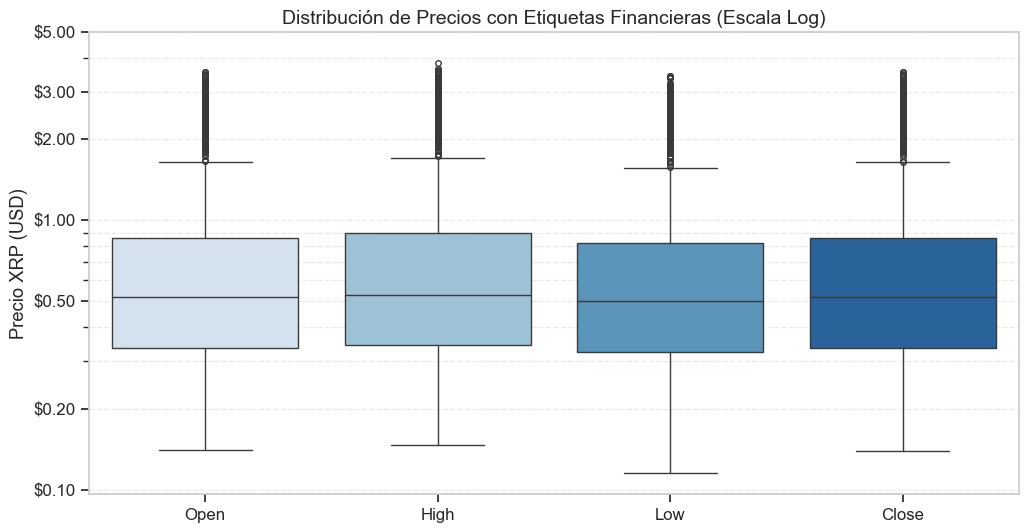

In [9]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette='Blues', fliersize=4)

# 1. Activamos la escala logarítmica
ax.set_yscale("log")

# 2. MEJORA: Forzamos etiquetas en formato moneda en lugar de potencias puras
# Esto mostrará 0.1, 1, 10 en lugar de 10^-1, 10^0, 10^1
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

# 3. Añadimos etiquetas específicas que tú quieras ver (opcional)
ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 3, 5]) 
ax.get_yaxis().set_major_formatter(ticker.FormatStrFormatter('$%.2f'))

# 4. Cuadrícula secundaria para ver los pasos intermedios
plt.grid(True, which="both", axis='y', ls="--", alpha=0.4)

plt.title('Distribución de Precios con Etiquetas Financieras (Escala Log)', fontsize=14)
plt.ylabel('Precio XRP (USD)')
plt.show()

### 📈 Conclusiones de la Distribución de precios

Tras visualizar la distribución de los precios de referencia mediante escalas logarítmicas y etiquetas financieras, se extraen las siguientes conclusiones clave para el proyecto:

1. **Estructura de Precios "Típicos"**: La mediana histórica de XRP se consolida en torno a los **$0.51**. El **50% central de los datos** (Rango Intercuartílico) se ubica entre los **$0.33 (Q1)** y los **$0.86 (Q3)**. Estadísticamente, este es el "canal de valor" histórico del activo.

2. **Asimetría Positiva (Positive Skewness)**: La presencia masiva de valores atípicos (**outliers**) en la parte superior del gráfico indica que XRP es propenso a picos de euforia o *bull runs* explosivos. Estos puntos representan desviaciones significativas que, aunque son "inusuales" para un modelo normal, son características intrínsecas de este mercado.

3. **Consistencia Operativa**: La similitud casi idéntica entre las cajas de *Open, High, Low y Close* confirma que no existen sesgos estructurales de apertura o cierre a largo plazo. Los datos han pasado las pruebas de jerarquía lógica ($Low \leq \{Open, Close\} \leq High$), validando la integridad del dataset para modelos predictivos.

4. **Justificación de Escala**: El uso de la escala logarítmica permite confirmar que XRP es un activo que se mueve por **proporciones relativas**. La dispersión observada valida que los movimientos de centavos en 2017 fueron tan significativos porcentualmente como los movimientos de dólares en años posteriores.